In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
pd.set_option('display.max_columns', None)


In [9]:
df = pd.read_parquet("../data/processed/spy_processed.parquet")
df.columns

Index(['symbol', 'expiration', 'strike', 'right', 'timestamp', 'bid', 'ask',
       'delta', 'theta', 'vega', 'rho', 'epsilon', 'lambda', 'implied_vol',
       'iv_error', 'underlying_timestamp', 'underlying_price', 'spy_close',
       'spy_open', 'log_return_from_open', 'ttm_min', 'log_return', 'd1',
       'gamma', 'open_interest', 'dex', 'gex'],
      dtype='str')

In [10]:
aggregate = pd.read_parquet("../data/processed/spy_aggregate.parquet")
aggregate.columns

Index(['timestamp', 'net_dex', 'net_gex', 'underlying_price', 'net_gex_norm',
       'net_dex_norm'],
      dtype='str')

In [11]:
# ATM IV: mean IV of call and put at the strike closest to spot for each timestamp
df2 = df.assign(dist=(df["strike"] - df["underlying_price"]).abs())
min_dist = df2.groupby("timestamp")["dist"].transform("min")
atm_iv = (
    df2[df2["dist"] == min_dist]
    .groupby("timestamp")["implied_vol"]
    .mean()
    .rename("atm_iv")
    .reset_index()
)
aggregate = aggregate.merge(atm_iv, on="timestamp", how="left")
aggregate

,timestamp,net_dex,net_gex,underlying_price,net_gex_norm,net_dex_norm,atm_iv
0,2026-05-06 09:45:00-04:00,-6.482183e+09,3.514162e+09,729.15,4.819533e+06,-8890054.53,0.16965
1,2026-05-06 10:00:00-04:00,-6.673169e+09,3.507746e+09,729.66,4.807371e+06,-9145586.46,0.16185
2,2026-05-06 10:15:00-04:00,-6.249268e+09,3.465909e+09,730.08,4.747301e+06,-8559702.83,0.16135
3,2026-05-06 10:30:00-04:00,-7.254773e+09,3.651162e+09,730.03,5.001387e+06,-9937636.19,0.16025
4,2026-05-06 10:45:00-04:00,-6.235425e+09,2.971337e+09,731.85,4.060035e+06,-8520086.28,0.14300
...,...,...,...,...,...,...,...
245,2026-05-19 14:45:00-04:00,1.357632e+09,-1.324910e+09,735.84,-1.800541e+06,1845010.04,0.23725
246,2026-05-19 15:00:00-04:00,1.671626e+09,-1.950403e+09,734.42,-2.655705e+06,2276117.74,0.27925
247,2026-05-19 15:15:00-04:00,1.285933e+09,-1.285623e+09,736.02,-1.746722e+06,1747143.67,0.22770
248,2026-05-19 15:30:00-04:00,2.363966e+09,-2.252909e+09,734.77,-3.066142e+06,3217287.20,0.20060


In [12]:
def calc_delta_iv(df: pd.DataFrame, target_delta: float) -> pd.DataFrame:
    """IV of call and put at target_delta (closest-delta formulation) per timestamp."""
    calls = df[df["right"] == "CALL"].copy()
    puts  = df[df["right"] == "PUT"].copy()

    calls["dist"] = (calls["delta"] - target_delta).abs()
    puts["dist"]  = (puts["delta"] - (-target_delta)).abs()

    min_call_dist = calls.groupby("timestamp")["dist"].transform("min")
    min_put_dist  = puts.groupby("timestamp")["dist"].transform("min")

    d = int(target_delta * 100)
    call_iv = calls[calls["dist"] == min_call_dist].groupby("timestamp")["implied_vol"].mean().rename(f"iv_call_{d}d")
    put_iv  = puts[puts["dist"] == min_put_dist].groupby("timestamp")["implied_vol"].mean().rename(f"iv_put_{d}d")

    return pd.concat([call_iv, put_iv], axis=1).reset_index()


aggregate = aggregate.merge(calc_delta_iv(df, 0.25), on="timestamp", how="left")
aggregate

,timestamp,net_dex,net_gex,underlying_price,net_gex_norm,net_dex_norm,atm_iv,iv_call_25d,iv_put_25d
0,2026-05-06 09:45:00-04:00,-6.482183e+09,3.514162e+09,729.15,4.819533e+06,-8890054.53,0.16965,0.1586,0.1875
1,2026-05-06 10:00:00-04:00,-6.673169e+09,3.507746e+09,729.66,4.807371e+06,-9145586.46,0.16185,0.1538,0.1928
2,2026-05-06 10:15:00-04:00,-6.249268e+09,3.465909e+09,730.08,4.747301e+06,-8559702.83,0.16135,0.1469,0.1840
3,2026-05-06 10:30:00-04:00,-7.254773e+09,3.651162e+09,730.03,5.001387e+06,-9937636.19,0.16025,0.1489,0.1826
4,2026-05-06 10:45:00-04:00,-6.235425e+09,2.971337e+09,731.85,4.060035e+06,-8520086.28,0.14300,0.1347,0.1696
...,...,...,...,...,...,...,...,...,...
245,2026-05-19 14:45:00-04:00,1.357632e+09,-1.324910e+09,735.84,-1.800541e+06,1845010.04,0.23725,0.2309,0.2597
246,2026-05-19 15:00:00-04:00,1.671626e+09,-1.950403e+09,734.42,-2.655705e+06,2276117.74,0.27925,0.2778,0.2871
247,2026-05-19 15:15:00-04:00,1.285933e+09,-1.285623e+09,736.02,-1.746722e+06,1747143.67,0.22770,0.2236,0.2329
248,2026-05-19 15:30:00-04:00,2.363966e+09,-2.252909e+09,734.77,-3.066142e+06,3217287.20,0.20060,0.1972,0.2060


In [15]:
aggregate['iv_skew_25d'] = aggregate['iv_put_25d'] - aggregate['iv_call_25d']
aggregate

,timestamp,net_dex,net_gex,underlying_price,net_gex_norm,net_dex_norm,atm_iv,iv_call_25d,iv_put_25d,iv_skew_25d
0,2026-05-06 09:45:00-04:00,-6.482183e+09,3.514162e+09,729.15,4.819533e+06,-8890054.53,0.16965,0.1586,0.1875,0.0289
1,2026-05-06 10:00:00-04:00,-6.673169e+09,3.507746e+09,729.66,4.807371e+06,-9145586.46,0.16185,0.1538,0.1928,0.0390
2,2026-05-06 10:15:00-04:00,-6.249268e+09,3.465909e+09,730.08,4.747301e+06,-8559702.83,0.16135,0.1469,0.1840,0.0371
3,2026-05-06 10:30:00-04:00,-7.254773e+09,3.651162e+09,730.03,5.001387e+06,-9937636.19,0.16025,0.1489,0.1826,0.0337
4,2026-05-06 10:45:00-04:00,-6.235425e+09,2.971337e+09,731.85,4.060035e+06,-8520086.28,0.14300,0.1347,0.1696,0.0349
...,...,...,...,...,...,...,...,...,...,...
245,2026-05-19 14:45:00-04:00,1.357632e+09,-1.324910e+09,735.84,-1.800541e+06,1845010.04,0.23725,0.2309,0.2597,0.0288
246,2026-05-19 15:00:00-04:00,1.671626e+09,-1.950403e+09,734.42,-2.655705e+06,2276117.74,0.27925,0.2778,0.2871,0.0093
247,2026-05-19 15:15:00-04:00,1.285933e+09,-1.285623e+09,736.02,-1.746722e+06,1747143.67,0.22770,0.2236,0.2329,0.0093
248,2026-05-19 15:30:00-04:00,2.363966e+09,-2.252909e+09,734.77,-3.066142e+06,3217287.20,0.20060,0.1972,0.2060,0.0088


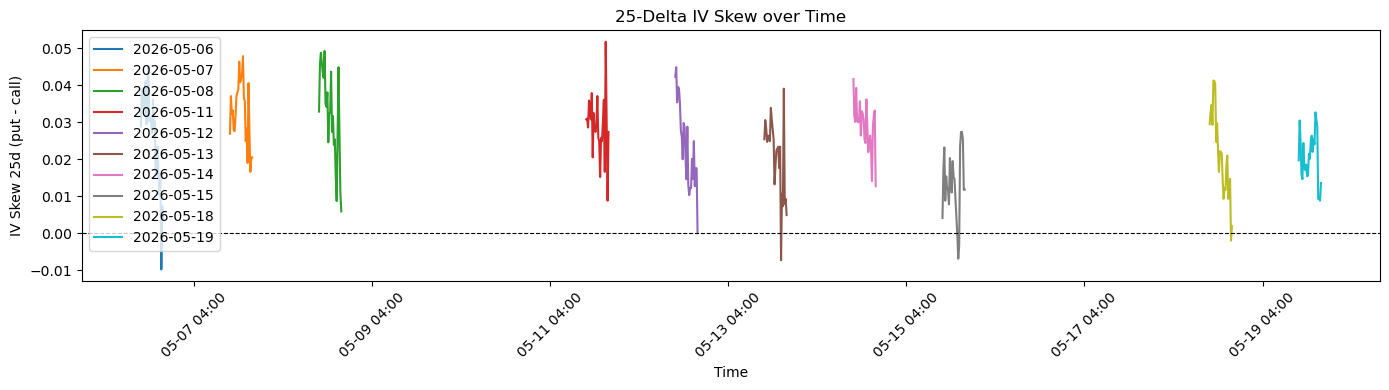

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in aggregate.groupby(aggregate["timestamp"].dt.date):
    ax.plot(group["timestamp"], group["iv_skew_25d"], label=str(date))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("IV Skew 25d (put - call)")
ax.set_title("25-Delta IV Skew over Time")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
aggregate['iv_smile_curvature_25d'] = aggregate['iv_call_25d'] + aggregate['iv_put_25d'] - 2 * aggregate['atm_iv']

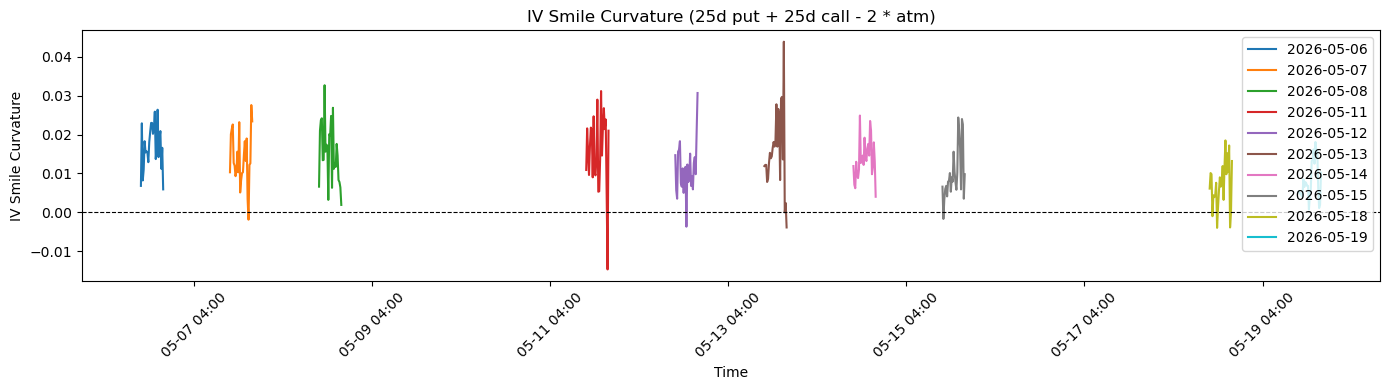

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in aggregate.groupby(aggregate["timestamp"].dt.date):
    ax.plot(group["timestamp"], group["iv_smile_curvature_25d"], label=str(date))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("IV Smile Curvature")
ax.set_title("IV Smile Curvature (25d put + 25d call - 2 * atm)")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
a = aggregate
b = pd.read_parquet("../data/processed/spy_aggregate.parquet")

print(f"Shape:  notebook={a.shape}  script={b.shape}")

only_a = set(a.columns) - set(b.columns)
only_b = set(b.columns) - set(a.columns)
print(f"Only in notebook: {only_a}")
print(f"Only in script:   {only_b}")

sort_keys = ["timestamp"]
common = [c for c in a.columns if c in b.columns]
a_s = a[common].sort_values(sort_keys).reset_index(drop=True)
b_s = b[common].sort_values(sort_keys).reset_index(drop=True)

for col in common:
    if pd.api.types.is_numeric_dtype(a_s[col]):
        if not np.allclose(a_s[col].fillna(0), b_s[col].fillna(0), rtol=1e-5, atol=1e-8):
            diff = (a_s[col] - b_s[col]).abs()
            print(f"MISMATCH {col}: max_diff={diff.max():.6g}, mean_diff={diff.mean():.6g}")
    else:
        mismatches = (a_s[col] != b_s[col]).sum()
        if mismatches:
            print(f"MISMATCH {col}: {mismatches} rows differ")

print("Done")

Shape:  notebook=(250, 11)  script=(250, 11)
Only in notebook: set()
Only in script:   set()
Done
